# Для решения шага 8 в уроке

**🧠🧠Задача: Сгенерируй killer фичу ☠️
**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

path = 'https://stepik.org/media/attachments/lesson/779914/make_it_easy.csv'
df = pd.read_csv(path)

In [2]:
df['killer_feature'] = np.sqrt(df['feature_1']**2 + df['feature_2']**2)

result = df.copy()
result.head()


,feature_1,feature_2,feature_3,label,killer_feature
0,2.5,0.00,58,B,2.500000
1,2.5,0.02,61,B,2.500080
2,2.5,0.05,33,B,2.500500
3,2.5,0.07,89,B,2.500980
4,2.5,0.10,58,B,2.501999


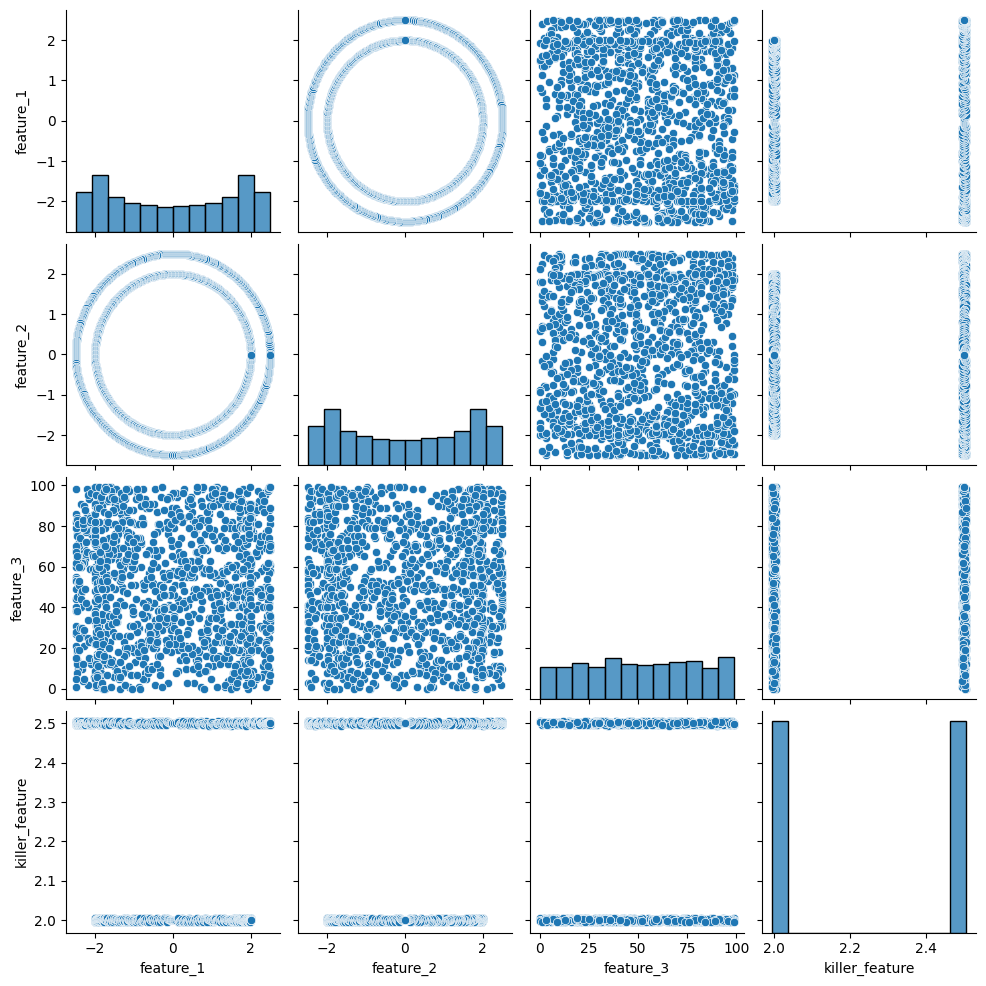

In [3]:
sns.pairplot(result);

#Для решения шага 9 в уроке

**🧠Задача: Сгенерируй ✌️ gold фичи 🥇**

In [4]:
import pandas as pd
path = 'https://stepik.org/media/attachments/lesson/779914/make_gold_features_example.csv'
df = pd.read_csv(path)

In [5]:
daily_avg = df.groupby(['car_id', 'ride_date'])['deviation_normal'].mean().reset_index()
daily_avg = daily_avg.sort_values(['car_id', 'ride_date'])

daily_avg['diff'] = daily_avg.groupby('car_id')['deviation_normal'].diff().fillna(-float('inf'))

max_diff_per_car = daily_avg.groupby('car_id')['diff'].max().reset_index()
max_diff_per_car.columns = ['car_id', 'gold_feature_1']

daily_avg['day_position'] = daily_avg.groupby('car_id').cumcount()

idx_max = daily_avg.groupby('car_id')['diff'].idxmax()
position_df = daily_avg.loc[idx_max, ['car_id', 'day_position']].reset_index(drop=True)
position_df.columns = ['car_id', 'gold_feature_2']

result = max_diff_per_car.merge(position_df, on='car_id')

result['gold_feature_1'] = result['gold_feature_1'].apply(lambda x: x if x >= 5 else 0)
result

,car_id,gold_feature_1,gold_feature_2
0,G-29,11.0,50
1,G115,52.0,49
2,M-30,8.0,51
3,b468,0.0,1
4,d-21,0.0,1


# Для решения шага 11 в уроке

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as  np

In [7]:
def plot_signal(df, max_cols=128, columns=None, signal_ids=[3, 13, 16, 256]):
    if columns is None:
        columns = [f"p{i}" for i in range(1, max_cols + 1)]
        
    # Переводим датасет в long формат
    df_melt = df.melt(
        id_vars="signal_id",
        value_vars=columns,
        var_name="orders",
        value_name="value",
    ).merge(df[["signal_id", "label"]], on="signal_id", how="left")

    # Отбираем несколько примеров разных классов
    tmp = df_melt[df_melt.signal_id.isin(signal_ids)]

    # Строим графику
    sns.relplot(
        data=tmp,
        x="orders",
        y="value",
        hue="label",
        style="signal_id",
        kind="line",
        aspect=3,
    ).set_xticklabels(rotation=45, horizontalalignment="right", step=2);

In [8]:
# Тренировочная выборка для поиска закономерности.

In [18]:
path = 'https://stepik.org/media/attachments/lesson/779914/fen_train.csv'
train_df = pd.read_csv(path)
train_df.head()

,signal_id,p1,p2,p3,p4,p5,p6,p7,p8,p9,...,p120,p121,p122,p123,p124,p125,p126,p127,p128,label
0,3,-0.177789,-0.081874,-0.096131,-0.099436,-0.098867,-0.105427,-0.083472,-0.074000,-0.065275,...,-0.068265,-0.059327,-0.013739,0.009359,0.009645,0.070163,0.108443,0.127638,0.099169,0
1,4,0.010337,0.010733,0.117607,0.259589,0.339589,0.329296,0.281260,0.115658,-0.172955,...,0.370135,0.344097,0.158927,-0.102145,-0.301141,-0.148649,0.263631,0.480440,0.420327,0
2,5,-0.221846,-0.247773,-0.187847,-0.181616,-0.108799,-0.099480,-0.083244,-0.054944,-0.100919,...,-0.086089,-0.080394,-0.089625,-0.122950,-0.074273,-0.018595,0.054752,0.097544,0.067837,0
3,6,0.411835,0.513823,0.558802,0.380244,0.210830,0.174093,0.102772,-0.051933,-0.237179,...,0.113856,0.014483,-0.112094,-0.133700,-0.024104,-0.042590,-0.062838,-0.078137,-0.194478,0
4,7,0.221770,-0.026863,-0.249447,-0.340728,-0.288676,-0.207364,-0.155768,-0.091768,-0.119012,...,-0.216549,-0.167078,-0.077491,-0.115439,-0.126838,-0.087323,-0.115734,-0.102995,-0.098657,0


In [94]:
max_cols = 128
point_columns = [f'p{i}' for i in range(1, max_cols + 1)]

def calculate_features(df, point_columns, threshold_zero_diff=0.05):
    df['mean'] = df[point_columns].mean(axis=1)
    df['std'] = df[point_columns].std(axis=1)
    df['variance'] = df[point_columns].var(axis=1)

    diffs = df[point_columns].diff(axis=1).fillna(0)
    df['zero_diff_count'] = (
        (diffs).abs().lt(threshold_zero_diff)
    ).sum(axis=1)
    return df

def plot_scatter(df, x_col, y_col, hue_col):
    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=df, x=x_col, y=y_col, hue=hue_col, palette={0: 'blue', 1: 'red', -1: 'green'})
    plt.title(f'Scatter plot of {y_col} vs {x_col}')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.legend(title=hue_col)
    plt.show()


In [101]:
class_0_median = train_df[train_df['label'] == 0][point_columns].diff(axis=1).abs().median().median()
class_1_median = train_df[train_df['label'] == 1][point_columns].diff(axis=1).abs().median().median()
threshold_zero_diff_median = (class_0_median + class_1_median) / 2

class_0_mean = train_df[train_df['label'] == 0][point_columns].diff(axis=1).abs().mean().mean()
class_1_mean = train_df[train_df['label'] == 1][point_columns].diff(axis=1).abs().mean().mean()
threshold_zero_diff_mean = (class_0_mean + class_1_mean) / 2

class_0_std = train_df[train_df['label'] == 0][point_columns].diff(axis=1).abs().std().std()
class_1_std = train_df[train_df['label'] == 1][point_columns].diff(axis=1).abs().std().std()
threshold_zero_diff_std = (class_0_std + class_1_std) / 2

print(f"Median of absolute differences for class 0: {class_0_median:.4f}")
print(f"Median of absolute differences for class 1: {class_1_median:.4f}")
print(f"Threshold for zero differences (median): {threshold_zero_diff_median:.4f}")

print(f"Mean of absolute differences for class 0: {class_0_mean:.4f}")
print(f"Mean of absolute differences for class 1: {class_1_mean:.4f}")
print(f"Threshold for zero differences (mean): {threshold_zero_diff_mean:.4f}")

Median of absolute differences for class 0: 0.0561
Median of absolute differences for class 1: 0.0633
Threshold for zero differences (median): 0.0597
Mean of absolute differences for class 0: 0.0808
Mean of absolute differences for class 1: 0.0761
Threshold for zero differences (mean): 0.0785


In [96]:
train_df[point_columns].diff().abs().lt(threshold_zero_diff).sum()

p1      65
p2      90
p3      85
p4      94
p5      73
        ..
p124    82
p125    78
p126    77
p127    92
p128    95
Length: 128, dtype: int64

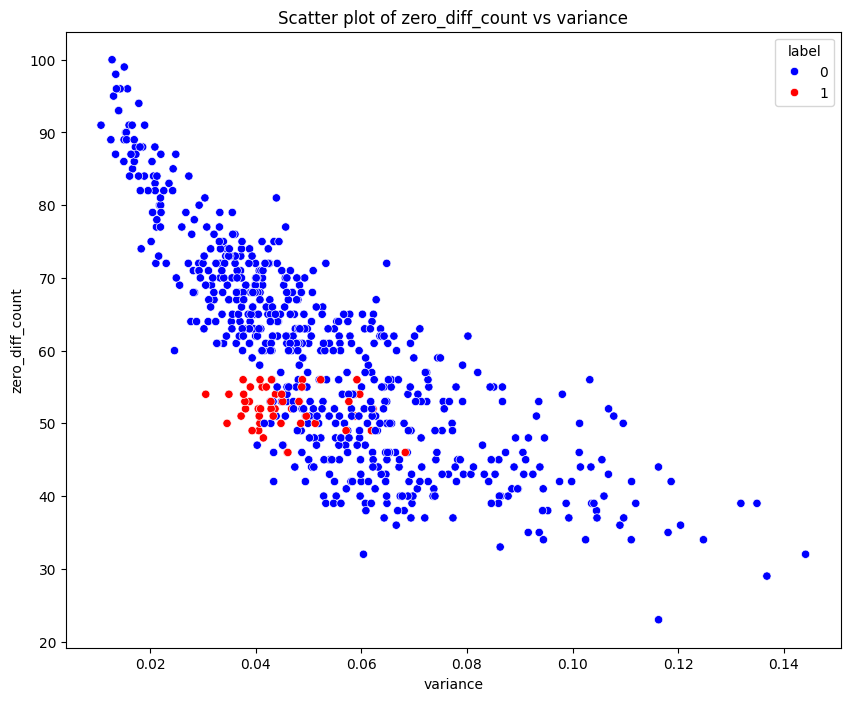

In [ ]:
# threshold_zero_diff = threshold_zero_diff_median
# threshold_zero_diff = threshold_zero_diff_mean
# threshold_zero_diff = threshold_zero_diff_std
threshold_zero_diff = 0.05

# расчет статистик ряда
# train_df = calculate_features(train_df, point_columns, threshold_zero_diff)
df['mean'] = tra[point_columns].mean(axis=1)
df['std'] = df[point_columns].std(axis=1)
df['variance'] = df[point_columns].var(axis=1)

diffs = df[point_columns].diff(axis=1).fillna(0)
df['zero_diff_count'] = (
    (diffs).abs().lt(threshold_zero_diff)
).sum(axis=1)

diffs_train = train_df[point_columns].diff(axis=1).fillna(0)
train_df['zero_diff_count'] = (
    (diffs_train).abs().lt(threshold_zero_diff)
).sum(axis=1)

# рассеивание признаков
plot_scatter(train_df, 'variance', 'zero_diff_count', 'label')

In [90]:

# рассеивание признаков
# sns.scatterplot(data=test_df, x='variance', y='zero_diff_count', hue='label');

In [91]:
# Ссылка на тестовую выборку для прогноза

In [92]:
path = 'https://stepik.org/media/attachments/lesson/779914/fen_test.csv'
test_df = pd.read_csv(path)
test_df.head()

,signal_id,p1,p2,p3,p4,p5,p6,p7,p8,p9,...,p119,p120,p121,p122,p123,p124,p125,p126,p127,p128
0,0,0.048383,0.075671,0.085861,0.087598,0.133466,0.239305,0.324572,0.264262,0.129173,...,0.138940,0.256082,0.344688,0.252258,0.034918,-0.141454,-0.132326,0.092708,0.290870,0.305827
1,1,0.092534,0.209535,0.390794,0.442508,0.429571,0.451524,0.310780,-0.075440,-0.297661,...,0.187563,0.234320,0.270503,0.328785,0.347625,0.426766,0.299061,-0.060183,-0.177051,-0.083738
2,8,0.045240,0.182892,0.293203,0.367133,0.341595,0.315698,0.343855,0.301613,0.243359,...,0.368040,0.290899,0.207095,0.242306,0.259203,0.210387,0.212587,0.076684,-0.203899,-0.346122
3,9,0.182414,-0.337581,-0.080484,0.393137,0.373783,0.112220,-0.219613,-0.355965,-0.302890,...,0.127023,0.275310,0.192306,0.073698,0.243584,0.276032,0.238793,0.275950,0.256591,0.360451
4,10,0.378236,0.137916,-0.063737,-0.201264,-0.067326,0.127712,0.221648,0.257548,0.093588,...,-0.202586,0.001186,0.190594,0.253443,0.168408,0.025194,-0.048555,-0.190483,-0.387497,-0.387843


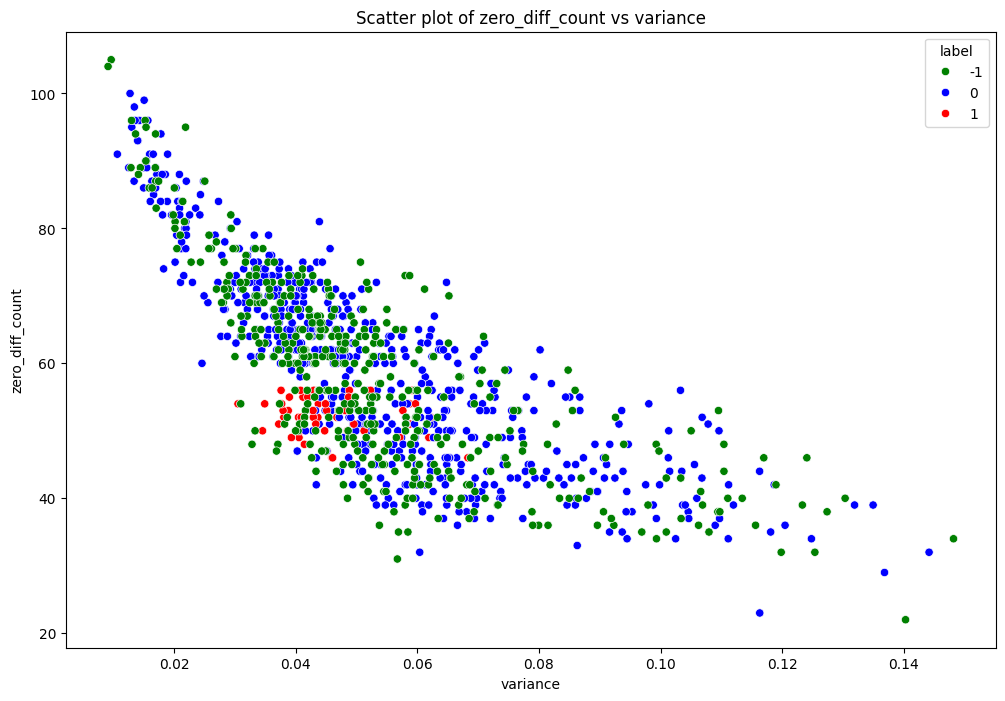

In [93]:
test_df = calculate_features(test_df, point_columns, threshold_zero_diff)

test_df['label'] = -1

train_test_df = pd.concat([train_df, test_df], ignore_index=True)

plot_scatter(train_test_df, 'variance', 'zero_diff_count', 'label')

In [15]:
# пример ответа для отправки

In [16]:
path = 'https://stepik.org/media/attachments/lesson/779914/fen_sample_solution.csv'
train = pd.read_csv(path)